# 0_02 — Protease manifest and event geometry

## Scope

Phase 1 of the calibration specification requires a protease manifest with an
explicit event geometry before any kinetic source is used. The manifest built
by `build_serum_manifest.py` carries identifiers but no geometry column. This
notebook resolves the geometry of each entry, reports what cannot be resolved,
and measures the consequences of the omission for the current scoring path.

Two properties of a peptidase are distinguished throughout. The geometry
determines which bonds are admissible events: every internal bond for an
endopeptidase, exactly one bond for an exopeptidase. An inadmissible position
is a forbidden event, not a weak site and not an observed non-cleavage.
`CleavagePotential` currently evaluates every protease against every bond.

Matrix quality is assessed in `0_01_merops_matrices.ipynb`; the
masking work that follows from this notebook belongs to
`1_merops_features/1_01`.

## Questions

1. How does the manifest correspond to the MEROPS panel, and what is
   unresolved?
2. What geometry does each entry have, and from which evidence?
3. What share of the currently scored (protease, bond) space is geometrically
   forbidden?
4. How does the background substitution at truncated windows change the score
   of terminal bonds, compared with an explicit subsite mask?

## Execution contract

**Inputs:** `data/serum_proteolysis_calibration/manifests/serum_proteases.tsv`; `data/merops/35_human_serum/codes.json`; `data/peptides_data/peptides_mic/peptides_apex.csv`.

**Outputs:** `results/0_02_serum_protease_geometry.csv`.

**Depends on:** none; the manifest is built by acquisition scripts, not by `0_01`.

**Boundary:** EC-based geometry does not show that a given enzyme is active in serum.

In [1]:
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

import _analysis_common as common
from pep_compass.optimization.components.helpers.proteolysis import (
    MEROPS_SUBSITES,
    CleavagePotential,
    EventGeometry,
    allowed_cut_positions,
    load_panel_metadata,
    load_protease_panel,
    masked_window_score,
    resolve_geometry,
)

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_PROBE_PEPTIDES = 1000
SEED = 20260920

In [3]:
print(f"device: {DEVICE}")

device: cuda


## Correspondence between the manifest and the MEROPS panel

The manifest and the MEROPS dataset must describe the same entries. A code
present in one and absent from the other would drop a protease from the model
without an error.

In [4]:
manifest = common.load_serum_manifest()
metadata = pd.DataFrame(load_panel_metadata(common.SERUM_DATASET_ID, merops_root=common.MEROPS_ROOT))
panel = metadata[["code", "name", "n_cleavages", "serum_category"]]

only_in_manifest = sorted(set(manifest["merops_code"]) - set(panel["code"]))
only_in_panel = sorted(set(panel["code"]) - set(manifest["merops_code"]))
print(f"manifest rows: {len(manifest)} | MEROPS panel entries: {len(panel)}")
print(f"codes only in the manifest: {only_in_manifest or 'none'}")
print(f"codes only in the MEROPS panel: {only_in_panel or 'none'}")
print()
print("mapping status:")
print(manifest["mapping_status"].value_counts().to_string())
print()
print(f"entries with an EC number: {(manifest['ec_number'] != '').sum()} / {len(manifest)}")
print(f"entries included in the hydrolysis model: {manifest['include_in_hydrolysis_model'].sum()}")

manifest rows: 55 | MEROPS panel entries: 55
codes only in the manifest: none
codes only in the MEROPS panel: none

mapping status:
mapping_status
mapped_reviewed                       51
unresolved_multiple_human_mappings     3
unresolved_no_human_mapping            1

entries with an EC number: 42 / 55
entries included in the hydrolysis model: 54


## Event geometry per entry

### Source of the assignment

The geometry is derived from the EC sub-subclass, because the peptidase section
of the EC hierarchy is organized by attack geometry: `3.4.11` aminopeptidases,
`3.4.14` dipeptidyl-peptidases, `3.4.15` peptidyl-dipeptidases, `3.4.16` to
`3.4.18` carboxypeptidases, `3.4.21` to `3.4.25` endopeptidases.

### Fallback and refusal

Entries whose UniProt record carries no EC number are matched against a name
rule. An entry that matches neither is assigned `unknown` and contributes no
admissible bond, rather than defaulting to an endopeptidase.

In [5]:
geometry_rows = []
for _, row in manifest.iterrows():
    geometry, source = resolve_geometry(
        row["ec_number"] or None,
        row["merops_name"],
        include_in_hydrolysis_model=bool(row["include_in_hydrolysis_model"]),
    )
    geometry_rows.append(
        {
            "merops_code": row["merops_code"],
            "merops_name": row["merops_name"],
            "merops_family": row["merops_family"],
            "serum_category": row["serum_category"],
            "uniprot_accession": row["uniprot_accession"],
            "ec_number": row["ec_number"],
            "mapping_status": row["mapping_status"],
            "include_in_hydrolysis_model": bool(row["include_in_hydrolysis_model"]),
            "event_geometry": geometry.value,
            "geometry_source": source,
        }
    )

geometry_frame = pd.DataFrame(geometry_rows).merge(
    panel.rename(columns={"code": "merops_code"})[["merops_code", "n_cleavages"]],
    on="merops_code",
    how="left",
)

print(
    pd.crosstab(geometry_frame["event_geometry"], geometry_frame["geometry_source"], margins=True).to_string()
)
print()
unresolved = geometry_frame.query("event_geometry == 'unknown'")
print(f"unresolved geometries: {len(unresolved)}")
if len(unresolved):
    print(unresolved[["merops_code", "merops_name", "ec_number", "mapping_status"]].to_string(index=False))

geometry_source       ec  manifest_exclusion  name  unresolved  All
event_geometry                                                     
aminopeptidase         1                   0     0           0    1
carboxypeptidase       2                   0     1           0    3
dipeptidyl_peptidase   1                   0     0           0    1
endopeptidase         36                   0     8           0   44
non_hydrolase          0                   1     0           0    1
peptidyl_dipeptidase   2                   0     0           0    2
unknown                0                   0     0           3    3
All                   42                   1     9           3   55

unresolved geometries: 3
merops_code                                         merops_name ec_number  mapping_status
    S01.033                     factor VII-activating peptidase           mapped_reviewed
    S01.132 mannan-binding lectin-associated serine peptidase-3           mapped_reviewed
    S01.198 mannan-bindi

In [6]:
exo_entries = geometry_frame.query(
    "event_geometry not in ['endopeptidase', 'non_hydrolase', 'unknown']"
)
print("non-endopeptidase entries in the serum panel:")
print(
    exo_entries[["merops_code", "merops_name", "event_geometry", "geometry_source", "n_cleavages"]]
    .sort_values("event_geometry")
    .to_string(index=False)
)

non-endopeptidase entries in the serum panel:
merops_code                                    merops_name       event_geometry geometry_source  n_cleavages
    M01.001                               aminopeptidase N       aminopeptidase              ec           42
    M02.006                angiotensin-converting enzyme-2     carboxypeptidase              ec           14
    M14.004                             carboxypeptidase N     carboxypeptidase            name           15
    M14.009                            carboxypeptidase B2     carboxypeptidase              ec           19
    S09.003            dipeptidyl-peptidase IV (eukaryote) dipeptidyl_peptidase              ec           29
    M02.001 angiotensin-converting enzyme peptidase unit 1 peptidyl_dipeptidase              ec            7
    M02.004 angiotensin-converting enzyme peptidase unit 2 peptidyl_dipeptidase              ec           13


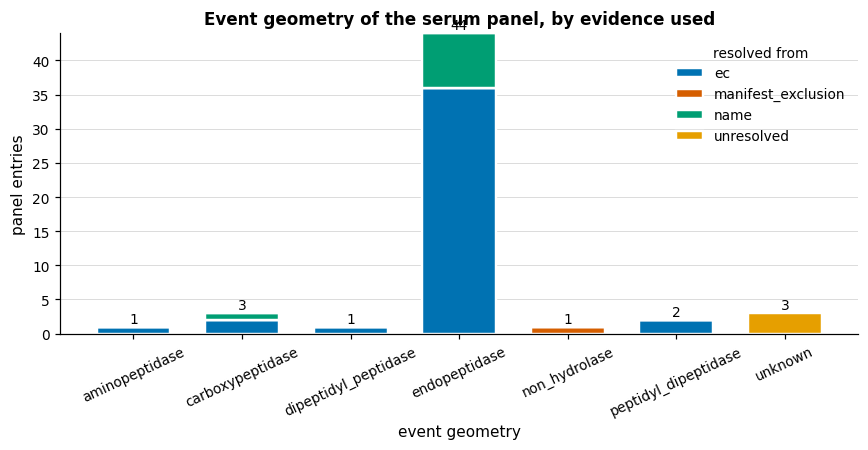

In [7]:
fig, ax = plt.subplots(figsize=(8.0, 4.2))
composition = (
    geometry_frame.groupby(["event_geometry", "geometry_source"]).size().unstack(fill_value=0)
)
bottom = np.zeros(len(composition))
for index, source in enumerate(composition.columns):
    ax.bar(
        composition.index,
        composition[source],
        bottom=bottom,
        color=common.CATEGORICAL_COLORS[index % len(common.CATEGORICAL_COLORS)],
        label=source,
        width=0.68,
        linewidth=1.6,
        edgecolor="white",
    )
    bottom += composition[source].to_numpy()
for position, total in enumerate(bottom):
    ax.text(position, total + 0.6, int(total), ha="center", fontsize=9)
ax.set_ylabel("panel entries")
ax.set_xlabel("event geometry")
ax.set_title("Event geometry of the serum panel, by evidence used")
ax.tick_params(axis="x", rotation=25)
ax.legend(title="resolved from", title_fontsize=9)
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

**Provenance**

`assets/scripts/downloads/serum_proteolysis_calibration/build_serum_manifest.py` reads `data/merops/35_human_serum/codes.json` in matrix-row order and excludes `C111.001` from hydrolysis; `map_uniprot_serum_proteases.py` adds reviewed human UniProt and EC mappings. Code cell 8 maps each manifest row to one event geometry by EC subclass or the explicit exclusion. The counting unit is one MEROPS code, grouped by `event_geometry`; `results/0_02_serum_protease_geometry.csv` contains 55 rows. Codes with unresolved EC or geometry remain explicit rather than becoming endopeptidases. Verify the `ec_number`, `mapping_status`, `event_geometry`, and `geometry_source` columns in the result and `data/serum_proteolysis_calibration/reports/unresolved_serum_proteases.tsv`. This classification constrains admissible cut positions; it does not measure cleavage frequency.


## Share of the scored space that is geometrically forbidden

`CleavagePotential` evaluates every protease against every bond. The admissible
space is smaller: an exopeptidase contributes one bond per peptide, and an
unresolved or non-hydrolytic entry contributes none. The ratio below is the
fraction of (protease, bond) pairs that enter the current panel sum without a
corresponding admissible event.

In [8]:
probe = (
    pd.read_csv(common.PEPTIDES_APEX_CSV, usecols=["sequence", "dataset"])
    .query("dataset.str.contains('dbaasp', case=False, na=False)")
    .drop_duplicates(subset=["sequence"])
    .sample(n=N_PROBE_PEPTIDES, random_state=SEED)
    .reset_index(drop=True)
)
probe_sequences = probe["sequence"].tolist()
lengths = probe["sequence"].str.len().to_numpy()

geometry_by_code = dict(zip(geometry_frame["merops_code"], geometry_frame["event_geometry"]))
panel_codes = list(panel["code"])

scored_pairs = 0
admissible_pairs = 0
per_geometry_pairs: dict[str, int] = {}
for length in lengths:
    n_bonds = int(length) - 1
    scored_pairs += n_bonds * len(panel_codes)
    for code in panel_codes:
        geometry = EventGeometry(geometry_by_code[code])
        allowed = int(allowed_cut_positions(int(length), geometry).sum())
        admissible_pairs += allowed
        per_geometry_pairs[geometry.value] = per_geometry_pairs.get(geometry.value, 0) + allowed

print(f"probe peptides: {len(probe_sequences)} (lengths {lengths.min()}-{lengths.max()})")
print(f"(protease, bond) pairs currently scored:   {scored_pairs:,}")
print(f"(protease, bond) pairs geometrically valid: {admissible_pairs:,}")
print(f"share of the scored space that is forbidden: {1 - admissible_pairs / scored_pairs:.3f}")
print()
print("admissible pairs by geometry:")
for name, value in sorted(per_geometry_pairs.items(), key=lambda item: -item[1]):
    print(f"  {name:24s} {value:>10,}")

probe peptides: 1000 (lengths 10-25)
(protease, bond) pairs currently scored:   869,935
(protease, bond) pairs geometrically valid: 702,948
share of the scored space that is forbidden: 0.192

admissible pairs by geometry:
  endopeptidase               695,948
  carboxypeptidase              3,000
  peptidyl_dipeptidase          2,000
  aminopeptidase                1,000
  dipeptidyl_peptidase          1,000
  non_hydrolase                     0
  unknown                           0


## Truncated windows under two scoring conventions

### The two conventions

A bond near a terminus has no $P_4$ or no $P_4'$. `CleavagePotential` fills the
missing subsites with a background distribution, which contributes a finite
term where no residue exists. The masked score of the specification sums only
the observed subsites.

### Putting them on one scale

The additive variant sums $\log M_{\pi,p,a_p}$ over all eight subsites; the
masked score sums $\log M_{\pi,p,a_p} - \log q_{a_p}$ over the observed ones.
Subtracting the constant $P \log q$ places both on the log-odds scale. A full
window must then agree exactly, and any remaining difference is the truncation
effect. The identity is asserted below before the effect is quantified.

In [9]:
logprob_panel = load_protease_panel(
    common.SERUM_DATASET_ID, merops_root=common.MEROPS_ROOT, kind="logprob", device=DEVICE
)
potential = CleavagePotential(logprob_panel, variant="additive", device=DEVICE)
matrices = logprob_panel.matrices.cpu().numpy().astype(np.float64)  # (N, P, A)

## The best evidenced endopeptidase carries the least matrix noise
endopeptidase_codes = [
    code for code in panel_codes if geometry_by_code[code] == EventGeometry.ENDOPEPTIDASE.value
]
focus_code = (
    panel[panel["code"].isin(endopeptidase_codes)].sort_values("n_cleavages", ascending=False).iloc[0]
)
focus_row = panel_codes.index(focus_code["code"])
print(f"focus protease: {focus_code['code']} — {focus_code['name']} ({int(focus_code['n_cleavages'])} cleavages)")

## One batched call returns the per-bond, per-protease values of every sequence
window_sequences = probe_sequences[:400]
per_bond_values, _ = potential.sequence_bond_protease_rates(window_sequences)

## REMARK: The additive variant returns a sum of log-probabilities over all eight
## subsites; the masked score is a sum of log-odds over the observed ones. The
## constant P * log q is removed so both live on the same scale.
log_odds_offset = len(MEROPS_SUBSITES) * np.log(1.0 / matrices.shape[-1])

records = []
for sequence, bond_values in zip(window_sequences, per_bond_values):
    length = len(sequence)
    unmasked = bond_values[:, focus_row] - log_odds_offset  # (L - 1,)
    for bond in range(length - 1):
        masked, observed = masked_window_score(sequence, bond, matrices[focus_row])
        distance_to_terminus = min(bond, length - 2 - bond)
        records.append(
            {
                "bond": bond,
                "distance_to_terminus": distance_to_terminus,
                "n_observed_subsites": observed,
                "unmasked_score": float(unmasked[bond]),
                "masked_score": masked,
            }
        )

window_frame = pd.DataFrame(records)
window_frame["difference"] = window_frame["unmasked_score"] - window_frame["masked_score"]

### Full windows must agree once the scale constant is removed. The tolerance is
### float32 round-off from the distributed matrices, not a modelling allowance.
full_windows = window_frame.query("n_observed_subsites == 8")
assert np.allclose(full_windows["difference"], 0.0, atol=1e-4), (
    "full windows must be identical under both conventions"
)
print(f"full-window agreement: max |difference| = {full_windows['difference'].abs().max():.2e}")
summary = window_frame.groupby("n_observed_subsites").agg(
    n_bonds=("bond", "size"),
    mean_unmasked=("unmasked_score", "mean"),
    mean_masked=("masked_score", "mean"),
    mean_difference=("difference", "mean"),
)
print()
print(summary.round(3).to_string())

interior_spread = full_windows["masked_score"].std()
truncated = window_frame.query("n_observed_subsites < 8")
print()
print(f"full-window bonds: {len(full_windows)} | truncated bonds: {len(truncated)} "
      f"({len(truncated) / len(window_frame):.1%} of all bonds)")
print(
    f"interior-bond spread (std of the masked score): {interior_spread:.3f}\n"
    f"largest mean truncation artefact: {summary['mean_difference'].abs().max():.3f} "
    f"({summary['mean_difference'].abs().max() / interior_spread:.2f} interior standard deviations)"
)

focus protease: M10.003 — matrix metallopeptidase-2 (3417 cleavages)


full-window agreement: max |difference| = 3.58e-06

                     n_bonds  mean_unmasked  mean_masked  mean_difference
n_observed_subsites                                                      
5                        800         -2.410       -1.285           -1.124
6                        800         -2.483       -1.746           -0.737
7                        800         -2.579       -2.375           -0.205
8                       3874         -1.670       -1.670           -0.000

full-window bonds: 3874 | truncated bonds: 2400 (38.3% of all bonds)
interior-bond spread (std of the masked score): 3.591
largest mean truncation artefact: 1.124 (0.31 interior standard deviations)


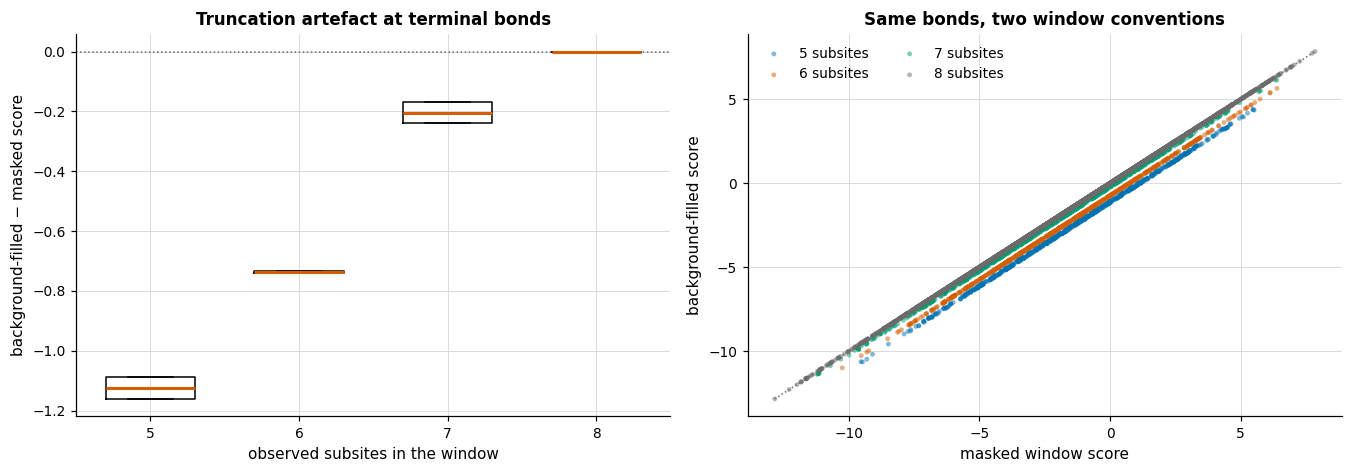

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.4))

ax = axes[0]
observed_levels = sorted(window_frame["n_observed_subsites"].unique())
ax.boxplot(
    [window_frame.query("n_observed_subsites == @level")["difference"] for level in observed_levels],
    positions=range(len(observed_levels)),
    widths=0.6,
    medianprops={"color": common.CATEGORICAL_COLORS[1], "linewidth": 2},
    flierprops={"marker": ".", "markersize": 3, "markerfacecolor": common.NEUTRAL, "markeredgecolor": "none"},
)
ax.axhline(0.0, color=common.NEUTRAL, linestyle=":", linewidth=1.0)
ax.set_xticks(range(len(observed_levels)))
ax.set_xticklabels(observed_levels)
ax.set_xlabel("observed subsites in the window")
ax.set_ylabel("background-filled − masked score")
ax.set_title("Truncation artefact at terminal bonds")

ax = axes[1]
for index, level in enumerate(observed_levels):
    subset = window_frame.query("n_observed_subsites == @level")
    ax.scatter(
        subset["masked_score"],
        subset["unmasked_score"],
        s=10,
        alpha=0.5,
        edgecolor="none",
        color=common.CATEGORICAL_COLORS[index % len(common.CATEGORICAL_COLORS)]
        if level != max(observed_levels)
        else common.NEUTRAL,
        label=f"{level} subsites",
    )
limits = [window_frame["masked_score"].min(), window_frame["masked_score"].max()]
ax.plot(limits, limits, color=common.NEUTRAL, linestyle=":", linewidth=1.0)
ax.set_xlabel("masked window score")
ax.set_ylabel("background-filled score")
ax.set_title("Same bonds, two window conventions")
ax.legend(loc="upper left", ncol=2)
fig.tight_layout()
plt.show()

**Provenance**

The probe sequences are read from `data/peptides_data/peptides_mic/peptides_apex.csv` in code cell 13: select `dataset` containing `dbaasp`, deduplicate by sequence, and sample `N_PROBE_PEPTIDES` with the shared seed. One counted opportunity is a `(MEROPS code, peptide bond)` pair; `allowed_cut_positions` removes geometrically forbidden pairs. For the truncation comparison, cell 15 uses the first 400 sampled sequences and the code with the largest `n_cleavages` among endopeptidases, then compares masked and unmasked scores by observed subsite count. These are model scores, not experimental cuts. Source acquisition and intermediate filter counts for the APEX probe: TODO: provenance do ustalenia.


## Geometry table

One row per manifest entry with its resolved geometry, the evidence used, and
the number of admissible bonds it contributes to a peptide of median probe
length. The table is read by `0_14_dataset_definition.ipynb` and by the
masking work in `1_merops_features/1_01`.

In [11]:
median_length = int(np.median(lengths))
geometry_frame["admissible_bonds_at_median_length"] = [
    int(allowed_cut_positions(median_length, EventGeometry(value)).sum())
    for value in geometry_frame["event_geometry"]
]
geometry_frame["scored_bonds_today"] = median_length - 1
geometry_frame["forbidden_bonds_today"] = (
    geometry_frame["scored_bonds_today"] - geometry_frame["admissible_bonds_at_median_length"]
)

destination = common.save_result(geometry_frame, "0_02_serum_protease_geometry.csv")
print(f"median probe length: {median_length} residues")
print(f"written: {destination.relative_to(common.ROOT)}")
geometry_frame.sort_values(["event_geometry", "merops_code"]).head(20)

median probe length: 17 residues
written: assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/0_02_serum_protease_geometry.csv


,merops_code,merops_name,merops_family,serum_category,uniprot_accession,ec_number,mapping_status,include_in_hydrolysis_model,event_geometry,geometry_source,n_cleavages,admissible_bonds_at_median_length,scored_bonds_today,forbidden_bonds_today
1,M01.001,aminopeptidase N,M01,metalloproteases_plasma,P15144,3.4.11.2,mapped_reviewed,True,aminopeptidase,ec,42,1,16,15
4,M02.006,angiotensin-converting enzyme-2,M02,metalloproteases_plasma,Q9BYF1,3.4.17.23,mapped_reviewed,True,carboxypeptidase,ec,14,1,16,15
16,M14.004,carboxypeptidase N,M14,metalloproteases_plasma,,,unresolved_multiple_human_mappings,True,carboxypeptidase,name,15,1,16,15
17,M14.009,carboxypeptidase B2,M14,metalloproteases_plasma,Q96IY4,3.4.17.20,mapped_reviewed,True,carboxypeptidase,ec,19,1,16,15
54,S09.003,dipeptidyl-peptidase IV (eukaryote),S09,metalloproteases_plasma,P27487,3.4.14.5,mapped_reviewed,True,dipeptidyl_peptidase,ec,29,1,16,15
5,M10.001,matrix metallopeptidase-1,M10,metalloproteases_plasma,P03956,3.4.24.7,mapped_reviewed,True,endopeptidase,ec,83,16,16,0
6,M10.002,matrix metallopeptidase-8,M10,metalloproteases_plasma,P22894,3.4.24.34,mapped_reviewed,True,endopeptidase,ec,114,16,16,0
7,M10.003,matrix metallopeptidase-2,M10,metalloproteases_plasma,P08253,3.4.24.24,mapped_reviewed,True,endopeptidase,ec,3417,16,16,0
8,M10.004,matrix metallopeptidase-9,M10,metalloproteases_plasma,P14780,3.4.24.35,mapped_reviewed,True,endopeptidase,ec,370,16,16,0
9,M10.005,matrix metallopeptidase-3,M10,metalloproteases_plasma,P08254,3.4.24.17,mapped_reviewed,True,endopeptidase,ec,2468,16,16,0
